PART A: DATASET PREPARATION AND TEXT PREPROCESSING

In [1]:
import nltk
import string

nltk.download('brown')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import brown, stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [2]:
sentences = brown.sents(categories='news')

print("Sample Sentences:")
for sentence in sentences[:3]:
    print(' '.join(sentence))

Sample Sentences:
The Fulton County Grand Jury said Friday an investigation of Atlanta's recent primary election produced `` no evidence '' that any irregularities took place .
The jury further said in term-end presentments that the City Executive Committee , which had over-all charge of the election , `` deserves the praise and thanks of the City of Atlanta '' for the manner in which the election was conducted .
The September-October term jury had been charged by Fulton Superior Court Judge Durwood Pye to investigate reports of possible `` irregularities '' in the hard-fought primary which was won by Mayor-nominate Ivan Allen Jr. .


In [3]:
text = ' '.join(' '.join(s) for s in sentences)

text = text.lower()

tokens = word_tokenize(text)

print("First 20 tokens:")
print(tokens[:20])

First 20 tokens:
['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', 'atlanta', "'s", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', '``']


In [4]:
stop_words = set(stopwords.words('english'))

filtered_tokens = [
    word for word in tokens
    if word not in string.punctuation
    and word not in stop_words
    and word.isalpha()
]

print("After removing punctuation and stop words:")
print(filtered_tokens[:20])

After removing punctuation and stop words:
['fulton', 'county', 'grand', 'jury', 'said', 'friday', 'investigation', 'atlanta', 'recent', 'primary', 'election', 'produced', 'evidence', 'irregularities', 'took', 'place', 'jury', 'said', 'presentments', 'city']


In [5]:
lemmatizer = WordNetLemmatizer()

processed_tokens = [
    lemmatizer.lemmatize(word)
    for word in filtered_tokens
]

print("After lemmatization:")
print(processed_tokens[:20])

After lemmatization:
['fulton', 'county', 'grand', 'jury', 'said', 'friday', 'investigation', 'atlanta', 'recent', 'primary', 'election', 'produced', 'evidence', 'irregularity', 'took', 'place', 'jury', 'said', 'presentment', 'city']


In [6]:
print("Original Text:")
print(text[:500])

print("\nPreprocessed Text:")
print(' '.join(processed_tokens[:100]))

Original Text:
the fulton county grand jury said friday an investigation of atlanta's recent primary election produced `` no evidence '' that any irregularities took place . the jury further said in term-end presentments that the city executive committee , which had over-all charge of the election , `` deserves the praise and thanks of the city of atlanta '' for the manner in which the election was conducted . the september-october term jury had been charged by fulton superior court judge durwood pye to invest

Preprocessed Text:
fulton county grand jury said friday investigation atlanta recent primary election produced evidence irregularity took place jury said presentment city executive committee charge election deserves praise thanks city atlanta manner election conducted term jury charged fulton superior court judge durwood pye investigate report possible irregularity primary ivan allen relative handful report received jury said considering widespread interest election number voter

PART B: VOCABULARY GENERATION AND WORD FREQUENCY ANALYSIS

In [7]:
from nltk.probability import FreqDist

vocabulary = set(processed_tokens)

freq_dist = FreqDist(processed_tokens)

print("Vocabulary Size:", len(vocabulary))

print("\nTop 10 Most Frequent Words:")
print(freq_dist.most_common(10))

print("\nFrequency of first 20 words:")
print(freq_dist.most_common(20))

Vocabulary Size: 9896

Top 10 Most Frequent Words:
[('said', 406), ('year', 260), ('would', 249), ('new', 241), ('state', 223), ('one', 222), ('last', 177), ('two', 174), ('first', 158), ('president', 155)]

Frequency of first 20 words:
[('said', 406), ('year', 260), ('would', 249), ('new', 241), ('state', 223), ('one', 222), ('last', 177), ('two', 174), ('first', 158), ('president', 155), ('home', 141), ('also', 129), ('school', 127), ('week', 125), ('time', 123), ('day', 117), ('member', 110), ('made', 107), ('house', 106), ('city', 105)]


In [8]:
from nltk.corpus import brown
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import string

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

processed_sentences = []

for sentence in brown.sents(categories='news'):
    tokens = word_tokenize(' '.join(sentence).lower())

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word.isalpha() and word not in stop_words
    ]

    if tokens:
        processed_sentences.append(tokens)

print("Total processed sentences:", len(processed_sentences))
print("\nSample processed sentences:")
for sentence in processed_sentences[:3]:
    print(sentence)

Total processed sentences: 4590

Sample processed sentences:
['fulton', 'county', 'grand', 'jury', 'said', 'friday', 'investigation', 'atlanta', 'recent', 'primary', 'election', 'produced', 'evidence', 'irregularity', 'took', 'place']
['jury', 'said', 'presentment', 'city', 'executive', 'committee', 'charge', 'election', 'deserves', 'praise', 'thanks', 'city', 'atlanta', 'manner', 'election', 'conducted']
['term', 'jury', 'charged', 'fulton', 'superior', 'court', 'judge', 'durwood', 'pye', 'investigate', 'report', 'possible', 'irregularity', 'primary', 'ivan', 'allen']


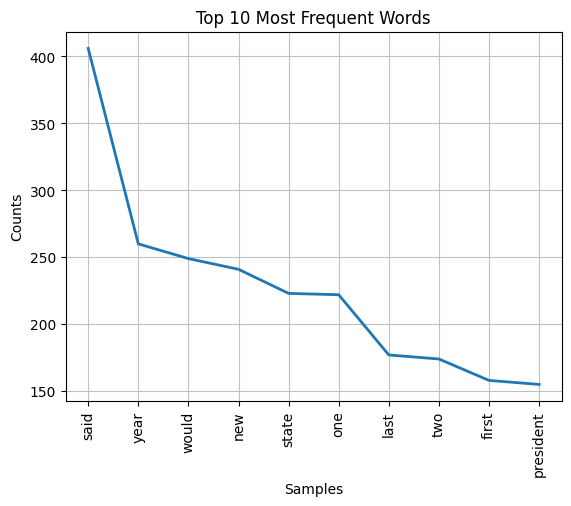

In [9]:
import matplotlib.pyplot as plt

freq_dist.plot(10, title="Top 10 Most Frequent Words")
plt.show()

PART C: WORD EMBEDDING GENERATION USING WORD2VEC

In [11]:
!pip install gensim

from gensim.models import Word2Vec

model = Word2Vec(
    sentences=processed_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,
    workers=4,
    epochs=10
)

print("Word2Vec model trained successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 50.5 MB/s eta 0:00:00
Word2Vec model trained successfully!


In [12]:
word = 'government'

if word in model.wv:
    vector = model.wv[word]

    print("Selected Word:", word)
    print("Embedding Vector:", vector)
    print("Vector Dimensions:", vector.shape)
else:
    print("Word not found in vocabulary.")

Selected Word: government
Embedding Vector: [-2.60138661e-01  1.20631784e-01  1.74276866e-02 -4.96909320e-02
 -4.72766869e-02 -1.01388343e-01 -4.93190996e-03  4.26880985e-01
 -2.17937753e-01  7.16704056e-02 -3.02715227e-02 -2.36773968e-01
  1.25417151e-02 -3.43645066e-02 -2.79040746e-02 -4.36734185e-02
  3.07457335e-02 -2.43638396e-01  1.07487716e-01 -4.13345724e-01
  1.23759462e-02  4.89415042e-03  6.69457484e-03 -6.46032989e-02
 -3.27576175e-02 -7.45374262e-02  5.05570844e-02 -2.40229294e-02
 -3.29243749e-01 -6.14677928e-03  2.33018562e-01  1.11333035e-01
 -1.24054134e-01 -1.75639406e-01  1.15614057e-01  8.13539773e-02
 -3.49245444e-02 -3.15429419e-01 -8.42398554e-02 -2.73332983e-01
 -5.19301295e-02 -1.64359704e-01 -1.02934696e-01 -1.72381252e-02
  3.28850597e-01 -1.95598185e-01 -2.22791210e-01  2.79761981e-02
  3.81545983e-02  1.40097827e-01  1.98108137e-01 -2.29672473e-02
  9.69743356e-03 -7.05297813e-02  8.16302449e-02  1.73170287e-02
 -3.89244854e-02  1.35344416e-01 -1.42186418e-

In [13]:
word = 'government'

if word in model.wv:
    similar_words = model.wv.most_similar(word, topn=5)

    print("Five Most Similar Words to:", word)

    for similar_word, score in similar_words:
        print(similar_word, ":", round(score, 4))
else:
    print("Word not found in vocabulary.")

Five Most Similar Words to: government
federal : 0.9735
department : 0.968
local : 0.9675
administration : 0.9614
program : 0.9612


PART D: WORD SIMILARITY ANALYSIS AND EXPERIMENT MANAGEMENT

In [14]:
from itertools import combinations

word_pairs = [
    ("government", "president"),
    ("government", "country"),
    ("government", "food")
]

print("Cosine Similarity Scores:\n")

results = []

for word1, word2 in word_pairs:
    if word1 in model.wv and word2 in model.wv:
        similarity = model.wv.similarity(word1, word2)
        results.append((word1, word2, similarity))
        print(f"{word1} - {word2}: {similarity:.4f}")
    else:
        print(f"{word1} - {word2}: One or both words not found.")

Cosine Similarity Scores:

government - president: 0.8503
government - country: 0.9385
government - food: 0.9188


In [15]:
if results:
    most_similar = max(results, key=lambda x: x[2])

    print("\nMost Similar Word Pair:")
    print(most_similar[0], "-", most_similar[1])
    print("Similarity Score:", round(most_similar[2], 4))


Most Similar Word Pair:
government - country
Similarity Score: 0.9385


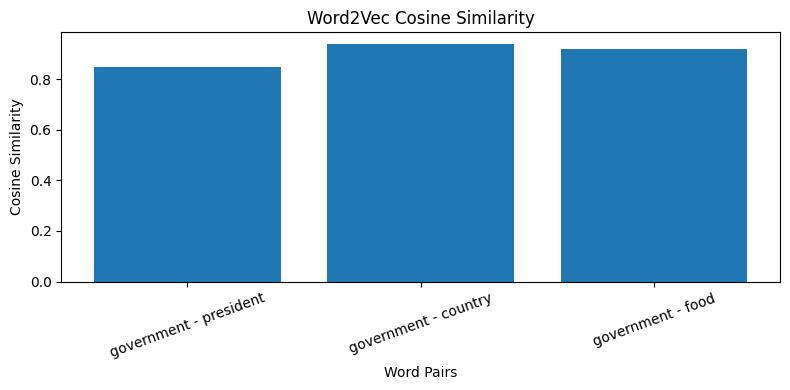

In [16]:
import matplotlib.pyplot as plt

if results:
    labels = [f"{w1} - {w2}" for w1, w2, score in results]
    scores = [score for w1, w2, score in results]

    plt.figure(figsize=(8, 4))
    plt.bar(labels, scores)
    plt.title("Word2Vec Cosine Similarity")
    plt.xlabel("Word Pairs")
    plt.ylabel("Cosine Similarity")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()